<a href="https://colab.research.google.com/github/Pradeep-1503/Sport-matches/blob/sport/sport_matches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load the data

### Subtask:
Load the student admission data from a CSV file into a pandas DataFrame.


**Reasoning**:
Import pandas, load the data, and display the head and info of the DataFrame.



**Reasoning**:
The previous command failed because the file was not found. I will try to list the files in the current directory to check if the file exists and its correct name.



     Year              Datetime    Stage         Stadium         City  \
0  1930.0  13 Jul 1930 - 15:00   Group 1         Pocitos  Montevideo    
1  1930.0  13 Jul 1930 - 15:00   Group 4  Parque Central  Montevideo    
2  1930.0  14 Jul 1930 - 12:45   Group 2  Parque Central  Montevideo    
3  1930.0  14 Jul 1930 - 14:50   Group 3         Pocitos  Montevideo    
4  1930.0  15 Jul 1930 - 16:00   Group 1  Parque Central  Montevideo    

  Home Team Name  Home Team Goals  Away Team Goals Away Team Name  \
0         France              4.0              1.0         Mexico   
1            USA              3.0              0.0        Belgium   
2     Yugoslavia              2.0              1.0         Brazil   
3        Romania              3.0              1.0           Peru   
4      Argentina              1.0              0.0         France   

  Win conditions  ...  Half-time Home Goals  Half-time Away Goals  \
0                 ...                   3.0                   0.0   
1       

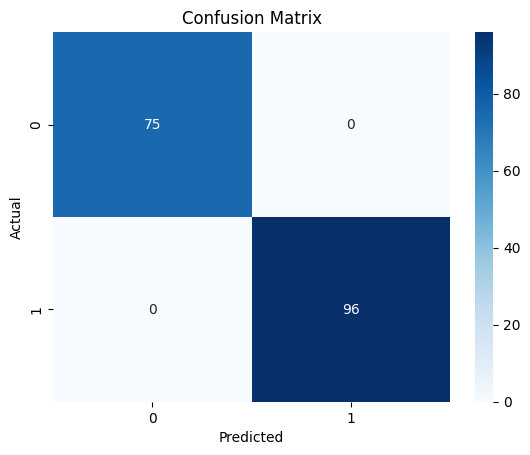

Prediction: Team 1 wins


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load historical data
# Sample structure: [team1_score, team2_score, team1_wins_last_5, team2_wins_last_5, player_rating_avg_team1, player_rating_avg_team2, outcome]
# Outcome: 1 if team1 wins, 0 if team2 wins
data = pd.read_csv('match_data.csv')

# Create 'outcome' column based on 'Home Team Goals' and 'Away Team Goals'
data['outcome'] = np.where(data['Home Team Goals'] > data['Away Team Goals'], 1, 0)


# 2. Explore data (optional)
print(data.head())
print(data.info())

# 3. Define features and target
# Exclude columns that are not relevant or could lead to data leakage
features = data.drop(columns=['outcome', 'Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name', 'Away Team Name', 'Win conditions', 'Attendance', 'Half-time Home Goals', 'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2', 'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials'])
target = data['outcome']

# Handle missing values by dropping rows with NaNs in features
features = features.dropna()
target = target[features.index] # Ensure target aligns with the cleaned features

# 4. Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# 5. Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# 6. Make predictions
y_pred = model.predict(X_test)

# 7. Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 8. Predicting a new match
# Example: [team1_score, team2_score, team1_wins_last_5, team2_wins_last_5, player_rating_avg_team1, player_rating_avg_team2]
# Note: The features used for prediction must match the features used for training the model.
# Based on the features defined in step 3, the new match data should only contain 'Home Team Goals' and 'Away Team Goals'.
new_match = np.array([[89, 82]]) # Example with only 'Home Team Goals' and 'Away Team Goals' as features
prediction = model.predict(new_match)
print("Prediction: Team 1 wins" if prediction[0] == 1 else "Prediction: Team 2 wins")

In [ ]:
import os
print(os.listdir())

['.config', 'loan_data (2).csv', 'loan_data (4).csv', 'loan_data (1).csv', '.ipynb_checkpoints', 'loan_data (3).csv', 'loan_data.csv', 'sample_data']
